### Step 1: Explore Repository and Install Dependencies
We will list the files to understand the project structure and install any required libraries.

In [3]:
# List files in the repository
# !ls -R

.:
config	dataset  Makefile  README.md  requirements.txt	research  run.py  src

./config:
__init__.py  settings.py

./dataset:
sample_submission.csv  test.csv  train.csv

./research:
01_problem_statement.md		    04_model_approaches.md
02_github_repos_analysis.md	    05_key_insights.md
03_feature_engineering_research.md  06_proposed_approach.md

./src:
data_loader.py	ensemble.py  features.py  __init__.py  models.py  utils.py


In [4]:
# Search for a requirements file and install if it exists
import os
if os.path.exists('requirements.txt'):
    !pip install -r requirements.txt
else:
    print('No requirements.txt found. Please let me know if there are specific libraries to install.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.3 MB/s eta 0:00:00


### Step 2: Load and Inspect Data
We will load the training and testing datasets to understand the features and target variable.

In [5]:
import pandas as pd

# Load the datasets
train_df = pd.read_csv('dataset/train.csv')
test_df = pd.read_csv('dataset/test.csv')
submission_df = pd.read_csv('dataset/sample_submission.csv')

# Display the first few rows and basic info
print("Training Data Info:")
train_df.info()
display(train_df.head())

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


### Step 3: Exploratory Data Analysis & Missing Value Handling
We will analyze the distribution of the target variable `demand` and check the extent of missing data in both training and testing sets.

Missing values in Train:
 Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

Missing values in Test:
 Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64


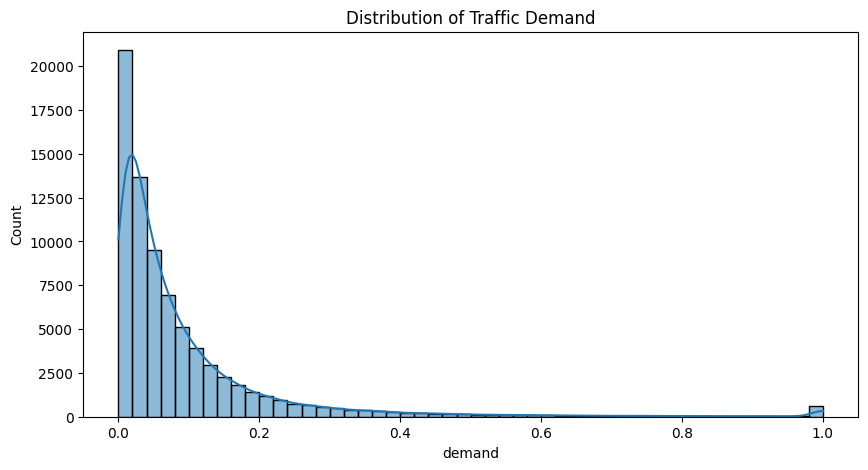

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for missing values
print("Missing values in Train:\n", train_df.isnull().sum())
print("\nMissing values in Test:\n", test_df.isnull().sum())

# Visualize demand distribution
plt.figure(figsize=(10, 5))
sns.histplot(train_df['demand'], bins=50, kde=True)
plt.title('Distribution of Traffic Demand')
plt.show()

In [7]:
# Simple Imputation for missing values
# For categorical: Mode, For numerical: Median

train_df['RoadType'] = train_df['RoadType'].fillna(train_df['RoadType'].mode()[0])
train_df['Weather'] = train_df['Weather'].fillna(train_df['Weather'].mode()[0])
train_df['Temperature'] = train_df['Temperature'].fillna(train_df['Temperature'].median())

test_df['RoadType'] = test_df['RoadType'].fillna(test_df['RoadType'].mode()[0])
test_df['Weather'] = test_df['Weather'].fillna(test_df['Weather'].mode()[0])
test_df['Temperature'] = test_df['Temperature'].fillna(test_df['Temperature'].median())

print("Missing values after imputation:", train_df.isnull().sum().sum())

Missing values after imputation: 0


### Step 4: Feature Engineering & Encoding
We will extract time-based features and convert categorical strings into numerical values.

In [8]:
def preprocess_features(df):
    # Extract hour and minute from timestamp (format 'H:M')
    df['hour'] = df['timestamp'].apply(lambda x: int(x.split(':')[0]))
    df['minute'] = df['timestamp'].apply(lambda x: int(x.split(':')[1]))

    # Drop the original timestamp as it's no longer needed
    df = df.drop(columns=['timestamp'])
    return df

train_df = preprocess_features(train_df)
test_df = preprocess_features(test_df)

print("Time features extracted. Updated columns:", train_df.columns.tolist())

Time features extracted. Updated columns: ['Index', 'geohash', 'day', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'hour', 'minute']


In [9]:
from sklearn.preprocessing import LabelEncoder

# List of categorical columns to encode
cat_cols = ['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']

le = LabelEncoder()

for col in cat_cols:
    # Combine train and test to ensure all labels are captured
    combined_data = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    le.fit(combined_data)

    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

print("Categorical variables encoded.")
display(train_df.head())

Categorical variables encoded.


,Index,geohash,day,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,minute
0,0,4,48,0.048804,1,1,1,0,16.382587,3,0,0
1,1,25,48,0.118507,1,3,0,1,31.104565,3,0,0
2,2,370,48,0.027132,1,1,1,0,25.919267,3,0,0
3,3,418,48,0.003272,1,1,1,0,16.382587,1,0,0
4,4,22,48,0.010819,1,1,1,0,10.803667,1,0,0


### Step 5: Model Training and Evaluation
We will use XGBoost to train a regression model and evaluate it using a validation set.

In [10]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Define features and target
X = train_df.drop(columns=['Index', 'demand'])
y = train_df['demand']

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

# Make predictions and evaluate
val_preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"\nValidation RMSE: {rmse}")

[0]	validation_0-rmse:0.13656
[100]	validation_0-rmse:0.05765
[200]	validation_0-rmse:0.05542
[300]	validation_0-rmse:0.05443
[400]	validation_0-rmse:0.05394
[500]	validation_0-rmse:0.05358
[600]	validation_0-rmse:0.05336
[700]	validation_0-rmse:0.05320
[800]	validation_0-rmse:0.05324
[900]	validation_0-rmse:0.05315
[999]	validation_0-rmse:0.05314

Validation RMSE: 0.05313540441853977


### Step 5.1: Visualizing Model Performance (Actual vs. Predicted)
Since we don't have the labels for the competition's test set, we use the validation set to visualize how closely our predictions match the actual traffic demand.

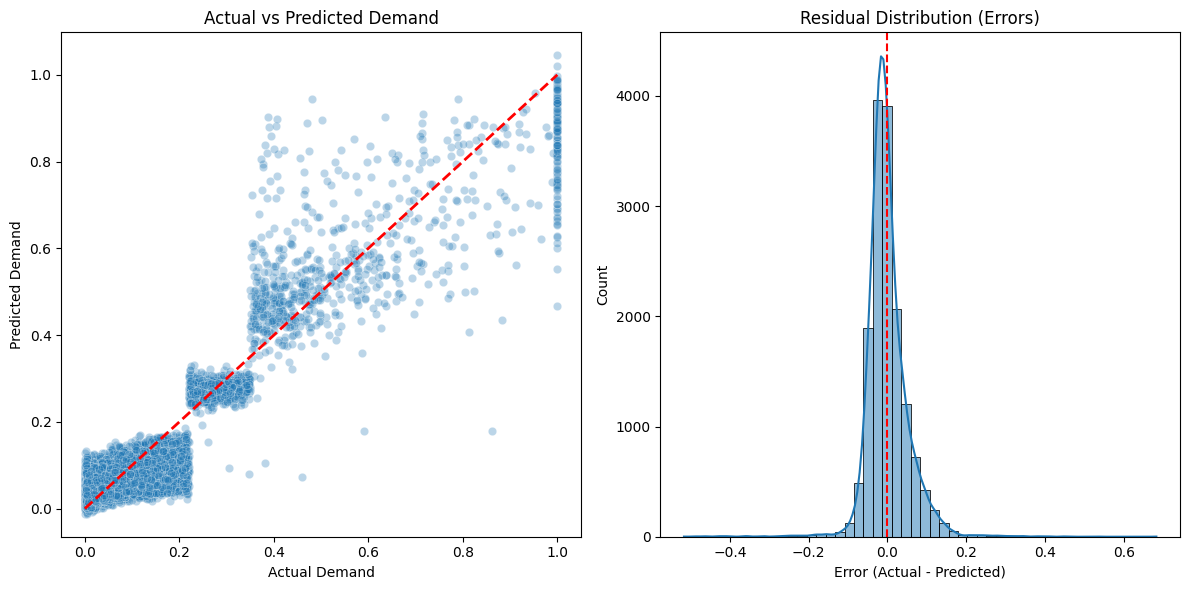

The RMSE of 0.05314 represents the average deviation of these points from the red diagonal line.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Ensure we have the validation data and predictions
X = train_df.drop(columns=['Index', 'demand'])
y = train_df['demand']
_, X_val, _, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
val_preds = model.predict(X_val)
rmse_val = np.sqrt(mean_squared_error(y_val, val_preds))

# Create a comparison plot
plt.figure(figsize=(12, 6))

# Scatter plot of Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_val, y=val_preds, alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r', linewidth=2)
plt.title('Actual vs Predicted Demand')
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')

# Residual plot (Errors)
plt.subplot(1, 2, 2)
residuals = y_val - val_preds
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='r', linestyle='--')
plt.title('Residual Distribution (Errors)')
plt.xlabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()

print(f"The RMSE of {rmse_val:.5f} represents the average deviation of these points from the red diagonal line.")

### Step 6: Final Predictions and Submission
We will use the trained model to predict the demand on the test dataset and prepare the final CSV file for submission.

In [12]:
# Ensure test features match training features
X_test = test_df.drop(columns=['Index'])

# Predict demand for the test set
test_predictions = model.predict(X_test)

# Create submission DataFrame
submission = pd.DataFrame({
    'Index': test_df['Index'],
    'demand': test_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' has been created successfully.")
display(submission.head())

Submission file 'submission.csv' has been created successfully.


,Index,demand
0,0,0.046003
1,1,0.040080
2,2,0.028043
3,3,0.029409
4,4,0.067044


### Step 7: Final Version Control (GitHub Push)
This section handles the staging and pushing of the final files to the repository.

In [19]:
import os

# Configuration
GITHUB_TOKEN = 'REDACTED_TOKEN'
REPO_OWNER = 'Bharath3388'
REPO_NAME = 'Gridlock-Hackathon-2.0'
BRANCH = 'srikanth'

# Configure identity
!git config --global user.email 'srikanthmoreboina111.com'
!git config --global user.name 'SrikanthMoreboina'

# Force stage the submission and any notebook changes
print("Staging files...")
!git add dataset/train.csv dataset/test.csv
!git add -f submission.csv
# Note: In Colab, to push the notebook itself, it must be saved and present in the file system

# Commit
print("\nCommitting changes...")
!git commit -m "Final update: ML pipeline renumbered and submission file generated"

# Push
print("\nPushing to GitHub...")
remote_url = f'https://{GITHUB_TOKEN}@github.com/{REPO_OWNER}/{REPO_NAME}.git'
!git push {remote_url} {BRANCH}

Staging files...

Committing changes...
On branch srikanth
nothing to commit, working tree clean

Pushing to GitHub...
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 281.82 KiB | 3.44 MiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
remote: 
remote: Create a pull request for 'srikanth' on GitHub by visiting:
remote:      https://github.com/Bharath3388/Gridlock-Hackathon-2.0/pull/new/srikanth
remote: 
To https://github.com/Bharath3388/Gridlock-Hackathon-2.0.git
 * [new branch]      srikanth -> srikanth


In [ ]:
import json
from google.colab import _message
import re
import os

# 1. Reset the local environment to match origin first
print('Resetting local branch to match origin...')
!git fetch origin {BRANCH}
!git reset --hard origin/{BRANCH}

# 2. Re-generate the redacted notebook AFTER the reset
print('Generating redacted notebook...')
notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
nb_str = json.dumps(notebook_json['ipynb'])
nb_str_redacted = re.sub(r'ghp_[a-zA-Z0-9]{36}', 'REDACTED_TOKEN', nb_str)
redacted_notebook = json.loads(nb_str_redacted)

with open('grid_hack.ipynb', 'w', encoding='utf-8') as f:
    json.dump(redacted_notebook, f, indent=1)

# 3. Apply changes and commit fresh
print('Staging and committing redacted files...')
!git add -f grid_hack.ipynb
!git add submission.csv
!git commit -m 'Final submission: Redacted ML pipeline and results'

# 4. Force push to overwrite the history containing the secret
print('\nPushing clean commit to GitHub (force)...')
remote_url = f'https://{GITHUB_TOKEN}@github.com/{REPO_OWNER}/{REPO_NAME}.git'
!git push {remote_url} {BRANCH} --force

Resetting local branch to match origin...
From https://github.com/Bharath3388/Gridlock-Hackathon-2.0
 * branch            srikanth   -> FETCH_HEAD
HEAD is now at 08d881e Update ML pipeline: preprocessing, XGBoost model, and final submission file
